In [1]:

from dataclasses import replace
from pathlib import Path

from pff import config_dir
from pff.config_classes.flow_pk_config import FlowPKConfig
from pff.data.datasets.aicme_datasets import AICMECompartmentsDataModule
from pff.models.amortized_inference.flows_pk import FlowPK
from tests.models.test_aicme_pk import _first_batch_list

# '/global/homes/d/dfarough/pff/config_files/experiment_configs/node-pk/flowPK.yaml'

default_yaml = Path(config_dir) / "experiment_configs/UAI" / "flow-pk-predict-n-generate" / "flowPK.yaml"
# default_yaml = Path(config_dir) / "experiment_configs/UAI" / "flow-pk-generative" / "flowPK.yaml"

cfg = FlowPKConfig.from_yaml(str(default_yaml))
model = FlowPK(cfg)

dm = AICMECompartmentsDataModule(cfg)
dm.prepare_data()
dm.setup()
loader = dm.train_dataloader()
batches = next(iter(loader))
batch = batches[0]
model._forward_reconstruction(batch)


/global/homes/d/dfarough/.conda/envs/pharma/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/global/u2/d/dfarough/pff/pff/models/utils/loss_utils.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.weights = torch.tensor(weights if weights else torch.ones(number_of_losses))


In [9]:
import torch
from pff.models.utils.scalers import PKScaler

scaler = PKScaler('zscore', 'max')
stats = scaler.stats(batch.context_obs, batch.context_obs_time, batch.context_obs_mask)

x_past, t_past = scaler.forward(batch.target_obs, batch.target_obs_time, stats) 
x_future, t_future = scaler.forward(batch.target_rem_sim, batch.target_rem_sim_time, stats) 

x_past = x_past * batch.target_obs_mask.unsqueeze(-1).float()
t_past = batch.target_obs_time
x_future = batch.target_rem_sim
x_future = x_future * batch.target_rem_sim_mask.unsqueeze(-1).float()
t_future = batch.target_rem_sim_time


In [11]:
import torch 
from pff.data.datasets.aicme_batch import AICMECompartmentsDataBatch


def concat_past_and_future(past_time, past_values, past_mask, future_time, future_values, future_mask):
    """
    Concatenate past and future observations for a single batch, moving padding to the end.
    Args:
        db: AICMECompartmentsDataBatch
    Returns:
        T: Concatenated times with padding at end. Shape: (B, n_substances, n_past+n_future, 1)
        X: Concatenated values with padding at end. Shape: (B, n_substances, n_past+n_future, n_features)
        M: Combined validity mask. Shape: (B, n_substances, n_past+n_future)
        is_future: Mask indicating future obs (True=future, False=past/padding). Shape: (B, n_substances, n_past+n_future)
    """
    # past_time = db.target_obs_time
    # past_values = db.target_obs
    # past_mask = db.target_obs_mask
    # future_time = db.target_rem_sim_time
    # future_values = db.target_rem_sim
    # future_mask = db.target_rem_sim_mask

    T_naive = torch.cat([past_time, future_time], dim=-2)
    X_naive = torch.cat([past_values, future_values], dim=-2)
    M_naive = torch.cat([past_mask, future_mask], dim=-1)

    n_past = past_time.shape[-2]
    n_future = future_time.shape[-2]
    device = past_time.device

    base_priority = torch.cat([
        torch.zeros(n_past, device=device),
        torch.ones(n_future, device=device)
    ])
    base_priority = base_priority.expand_as(M_naive)
    priority = torch.where(M_naive, base_priority, base_priority + 2)
    sort_indices = torch.argsort(priority, dim=-1, stable=True)
    sort_indices_expanded = sort_indices.unsqueeze(-1)
    T = torch.gather(T_naive, dim=-2, index=sort_indices_expanded)
    X = torch.gather(X_naive, dim=-2, index=sort_indices_expanded.expand_as(X_naive))
    M = torch.gather(M_naive, dim=-1, index=sort_indices)
    original_is_future = torch.cat([
        torch.zeros(n_past, dtype=torch.bool, device=device),
        torch.ones(n_future, dtype=torch.bool, device=device)
    ]).expand_as(M_naive)
    is_future = torch.gather(original_is_future, dim=-1, index=sort_indices)
    is_future = is_future & M
    return T, X, M, is_future


def split_past_and_future(
        self,
        T: torch.Tensor,
        X: torch.Tensor,
        M: torch.Tensor,
        is_future: torch.Tensor,
        n_future: int,
        )   :
        """Inverse of concat_past_future: extract future observations from concatenated tensor.

        Args:
            T:         (B, I, n_past + n_future, 1)  - concatenated times
            X:         (B, I, n_past + n_future, F)  - concatenated values
            M:         (B, I, n_past + n_future)     - combined validity mask
            is_future: (B, I, n_past + n_future)     - True where position is a valid future obs
            n_future:  int                         - original number of future time slots
        Returns:
            future_time:   (B, I, n_future, 1)
            future_values: (B, I, n_future, F)
            future_mask:   (B, I, n_future)        - True where slot has a valid future obs
        """
        B, I, N, F = X.shape
        device = X.device

        # Indices of the n_future future slots per (b, i), in sorted order.
        # is_future has at most n_future True entries per row; pad with N (out-of-bounds) if fewer.
        # argsort with ~is_future last gives future indices first (stable so order is preserved).
        future_order = torch.argsort(~is_future, dim=-1, stable=True)  # (B, I, N): future idx first
        future_idx = future_order[..., :n_future]                      # (B, I, n_future)

        future_mask = torch.gather(is_future, dim=-1, index=future_idx)  # (B, I, n_future)

        idx_expanded = future_idx.unsqueeze(-1)                          # (B, I, n_future, 1)
        future_time   = torch.gather(T, dim=-2, index=idx_expanded)      # (B, I, n_future, 1)
        future_values = torch.gather(X, dim=-2, index=idx_expanded.expand(B, I, n_future, F))

        return future_time, future_values, future_mask


# Apply to batch
T, X, M, is_future = concat_past_and_future(t_past, x_past, batch.target_obs_mask, t_future, x_future, batch.target_rem_sim_mask)

print(f"T shape: {T.shape}")
print(f"X shape: {X.shape}")
print(f"M shape: {M.shape}")
print(f"is_future shape: {is_future.shape}")

T shape: torch.Size([64, 1, 20, 1])
X shape: torch.Size([64, 1, 20, 1])
M shape: torch.Size([64, 1, 20])
is_future shape: torch.Size([64, 1, 20])


In [57]:
# Verify the result for sample n
n = 3
print("=== Original Past ===")
print(f"Times:  {batch.target_obs_time[n, 0, :, 0].tolist()}")
print(f"Values: {batch.target_obs[n, 0, :, 0].tolist()}")
print(f"Mask:   {batch.target_obs_mask[n, 0, :].tolist()}")

print("\n=== Original Future ===")
print(f"Times:  {batch.target_rem_sim_time[n, 0, :, 0].tolist()}")
print(f"Values: {batch.target_rem_sim[n, 0, :, 0].tolist()}")
print(f"Mask:   {batch.target_rem_sim_mask[n, 0, :].tolist()}")

print("\n=== Combined (properly reordered) ===")
print(f"Times:     {T[n, 0, :, 0].tolist()}")
print(f"Values:    {X[n, 0, :, 0].tolist()}")
print(f"Mask:      {M[n, 0, :].tolist()}")
print(f"Is Future: {is_future[n, 0, :].tolist()}")

=== Original Past ===
Times:  [0.808080792427063, 1.454545497894287, 3.7171716690063477, 0.0, 0.0]
Values: [0.058334872126579285, 0.08149192482233047, 0.10665919631719589, 0.0, 0.0]
Mask:   [True, True, True, False, False]

=== Original Future ===
Times:  [5.818181991577148, 7.2727274894714355, 9.373737335205078, 11.313131332397461, 15.353535652160645, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Values: [0.10450869053602219, 0.10272295773029327, 0.09855807572603226, 0.09535437822341919, 0.08761554211378098, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Mask:   [True, True, True, True, True, False, False, False, False, False, False, False, False, False, False]

=== Combined (properly reordered) ===
Times:     [0.052631575614213943, 0.09473684430122375, 0.24210526049137115, 0.378947377204895, 0.4736842215061188, 0.6105263233184814, 0.7368420958518982, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Values:    [0.318559855222702, 0.4450177848339081, 0.5824532508

In [12]:
from typing import Union

import torch
import torch.nn as nn
from torchtyping import TensorType

class GaussianProcessRegression(nn.Module):
    """
    GP regression that conditions on a (variable-length) conditional observations
    and draws a posterior sample over the full time grid.

    Parameters
    ----------
    variance     : RBF kernel output scale  σ²
    length_scale : RBF length scale L
    epsilon       : diagonal regularisation added to the prior covariance
                   for Cholesky numerical stability
    transform     : "none" | "exp" | "softplus" applied to the output to ensure positive concentrations

    """

    def __init__(
        self,
        variance: float = 1.0,
        length_scale: float = 1.0,
        epsilon: float = 1e-7, 
        transform: str = "softplus", 
    ):
        super().__init__()
        self.var = variance
        self.L = length_scale
        self.epsilon = epsilon
        self.transform = transform

    def _forward_transform(self, x: torch.Tensor) -> torch.Tensor:
        """Map unconstrained GP output → positive space."""
        if self.transform == "exp":
            return torch.exp(x)
        if self.transform == "softplus":
            return torch.nn.functional.softplus(x)
        return x

    def _rbf(
        self,
        t1: TensorType["B", "N1", 1],
        t2: TensorType["B", "N2", 1],
        ) -> TensorType["B", "N1", "N2"]:
        """Batched RBF (squared-exponential) kernel."""
        dist = t1 - t2.transpose(-1, -2)          # (B, N1, N2)
        return self.var * torch.exp(-torch.square(dist / self.L))

    def sample_prior(
        self,
        t_query:    TensorType["B", 1, "N", 1],
        mask_query: Union[TensorType["B", 1, "N"], None] = None,
        **kwargs,
    ) -> TensorType["B", 1, "N", 1]:
        """
        Sample from the GP prior (no conditioning data).

        Parameters
        ----------
        t_query    : (B, 1, N, 1)  query time points, zero-padded.
        mask_query : (B, *, N) bool, optional — True = real time point.
                     Inferred from t_query > 0 when not supplied.

        Returns
        -------
        x_query : (B, 1, N, 1)
            GP prior sample at each t_query point.
            Values at padded slots are zeroed out.
        """
        B, _, N, _ = t_query.shape
        device, dtype = t_query.device, t_query.dtype
        tq = t_query.reshape(B, N)                          # (B, N)
        mask_query = mask_query.reshape(B, N) if mask_query  is not None else torch.ones_like(tq)
        K_qq = self._rbf(tq.unsqueeze(-1), tq.unsqueeze(-1))   # (B, N, N)
        diag_eps_q = torch.where(
            mask_query,
            tq.new_full((B, N), self.epsilon),
            tq.new_ones((B, N)),
        )
        K_qq = K_qq + torch.diag_embed(diag_eps_q)             # (B, N, N)
        L_chol  = torch.linalg.cholesky(K_qq)                  # (B, N, N)
        z       = torch.randn(B, N, 1, device=device, dtype=dtype)
        x_query = (L_chol @ z).squeeze(-1)                     # (B, N)
        x_query = self._forward_transform(x_query)
        x_query = x_query * mask_query
        return x_query.reshape(B, 1, N, 1)

    # ------------------------------------------------------------------
    def forward(
        self,
        t_query:    TensorType["B", 1, "N", 1],
        t_cond:     Union[TensorType["B", 1, "M", 1], None] = None,
        x_cond:     Union[TensorType["B", 1, "M", 1], None] = None,
        mask_query: Union[TensorType["B", 1, "N"], None] = None,
        mask_cond:  Union[TensorType["B", 1, "M"], None] = None,
        ) -> TensorType["B", 1, "N", 1]:
        """
        Parameters
        ----------
        t_query    : (B, 1, N, 1)  query time points.
        t_cond     : (B, 1, M, 1)  conditioning time points. If None (along
                     with x_cond), samples from the GP prior.
        x_cond     : (B, 1, M, 1)  observed values at t_cond. If None (along
                     with t_cond), samples from the GP prior.
        mask_query : (B, *, N) bool, zero-padded query points
        mask_cond  : (B, *, M) bool, zero-padded conditioning points
        Returns
        -------
        x_query : (B, 1, N, 1)
            GP posterior sample (or prior sample when no conditioning data)
            at each t_query point. Values at padded future slots are zeroed out.
        """

        B, _, N, _ = t_query.shape
        device, dtype = t_query.device, t_query.dtype

        if t_cond is None or x_cond is None:
            return self.sample_prior(t_query, mask_query=mask_query)

        M = t_cond.shape[2]
        tq = t_query.reshape(B, N)
        tc = t_cond.reshape(B, M)
        xc = x_cond.reshape(B, M)
        mask_cond = mask_cond.reshape(B, M) if mask_cond is not None else torch.ones_like(tc)
        mask_query = mask_query.reshape(B, N) if mask_query  is not None else torch.ones_like(tq)

        #...kernel matrices

        K_cc = self._rbf(tc.unsqueeze(-1), tc.unsqueeze(-1))               # (B, M, M)
        K_qc = self._rbf(tq.unsqueeze(-1), tc.unsqueeze(-1))               # (B, N, M)
        K_qq = self._rbf(tq.unsqueeze(-1), tq.unsqueeze(-1))               # (B, N, N)

        #...regularize K's

        diag_eps_c = torch.where(
            mask_cond,
            tc.new_full((B, M), self.epsilon),
            tc.new_full((B, M), 1e+10),
        )
        diag_eps_q = torch.where(
            mask_query,
            tq.new_full((B, N), self.epsilon),
            tq.new_ones((B, N)),
        )
        K_cc = K_cc + torch.diag_embed(diag_eps_c)                  # (B, N, N)
        K_qq = K_qq + torch.diag_embed(diag_eps_q)                  # (B, N, N)
        has_cond_data = mask_cond.any(dim=-1)                       # (B,)

        #...GP posterior

        # alpha = K_cc^{-1} x_cond                                  (B, M, 1)
        alpha = torch.linalg.solve(K_cc, xc.unsqueeze(-1))
        post_mean = (K_qc @ alpha).squeeze(-1)                  #   (B, N)

        # Posterior cov   Σ_q = K_qq − K_qc K_cc^{-1} K_cq          (B, N, N)
        V = torch.linalg.solve(K_cc, K_qc.transpose(-1, -2))    #   (B, M, N)
        post_cov = K_qq - K_qc @ V                              #   (B, N, N)

        #...posterior sample
        L_chol   = torch.linalg.cholesky(post_cov)                   # (B, N, N)
        z        = torch.randn(B, N, 1, device=device, dtype=dtype)
        x_query = post_mean + (L_chol @ z).squeeze(-1)               # (B, N)

        #...prior fallback: batch elements with no observations → sample from prior GP
        if not has_cond_data.all():
            no_cond   = ~has_cond_data
            L_prior  = torch.linalg.cholesky(K_qq[no_cond])           # (n, N, N)
            z_prior  = torch.randn(no_cond.sum(), N, 1, device=device, dtype=dtype)
            x_query = x_query.clone()
            x_query[no_cond] = (L_prior @ z_prior).squeeze(-1)

        x_query = self._forward_transform(x_query)
        x_query = x_query * mask_query # zero out padded future slots
        return x_query.reshape(B, 1, N, 1)

In [13]:

GPR = GaussianProcessRegression(variance=0.01, length_scale=0.01, transform='None')
x_future = GPR(
    t_query=t_future,  # (B, 1, N, 1)
    t_cond=t_past,  # (B, 1, N, 1)
    x_cond=x_past + 1e-8,    # (B, 1, M, 1)
    mask_cond = batch.target_obs_mask,  # (B, 1, M)  — optional
    mask_query = batch.target_rem_sim_mask,  # (B, 1, N)  — optional
) 

T, X, M, is_future = concat_past_and_future(t_past, x_past+ 1e-8, batch.target_obs_mask, t_future, x_future, batch.target_rem_sim_mask)


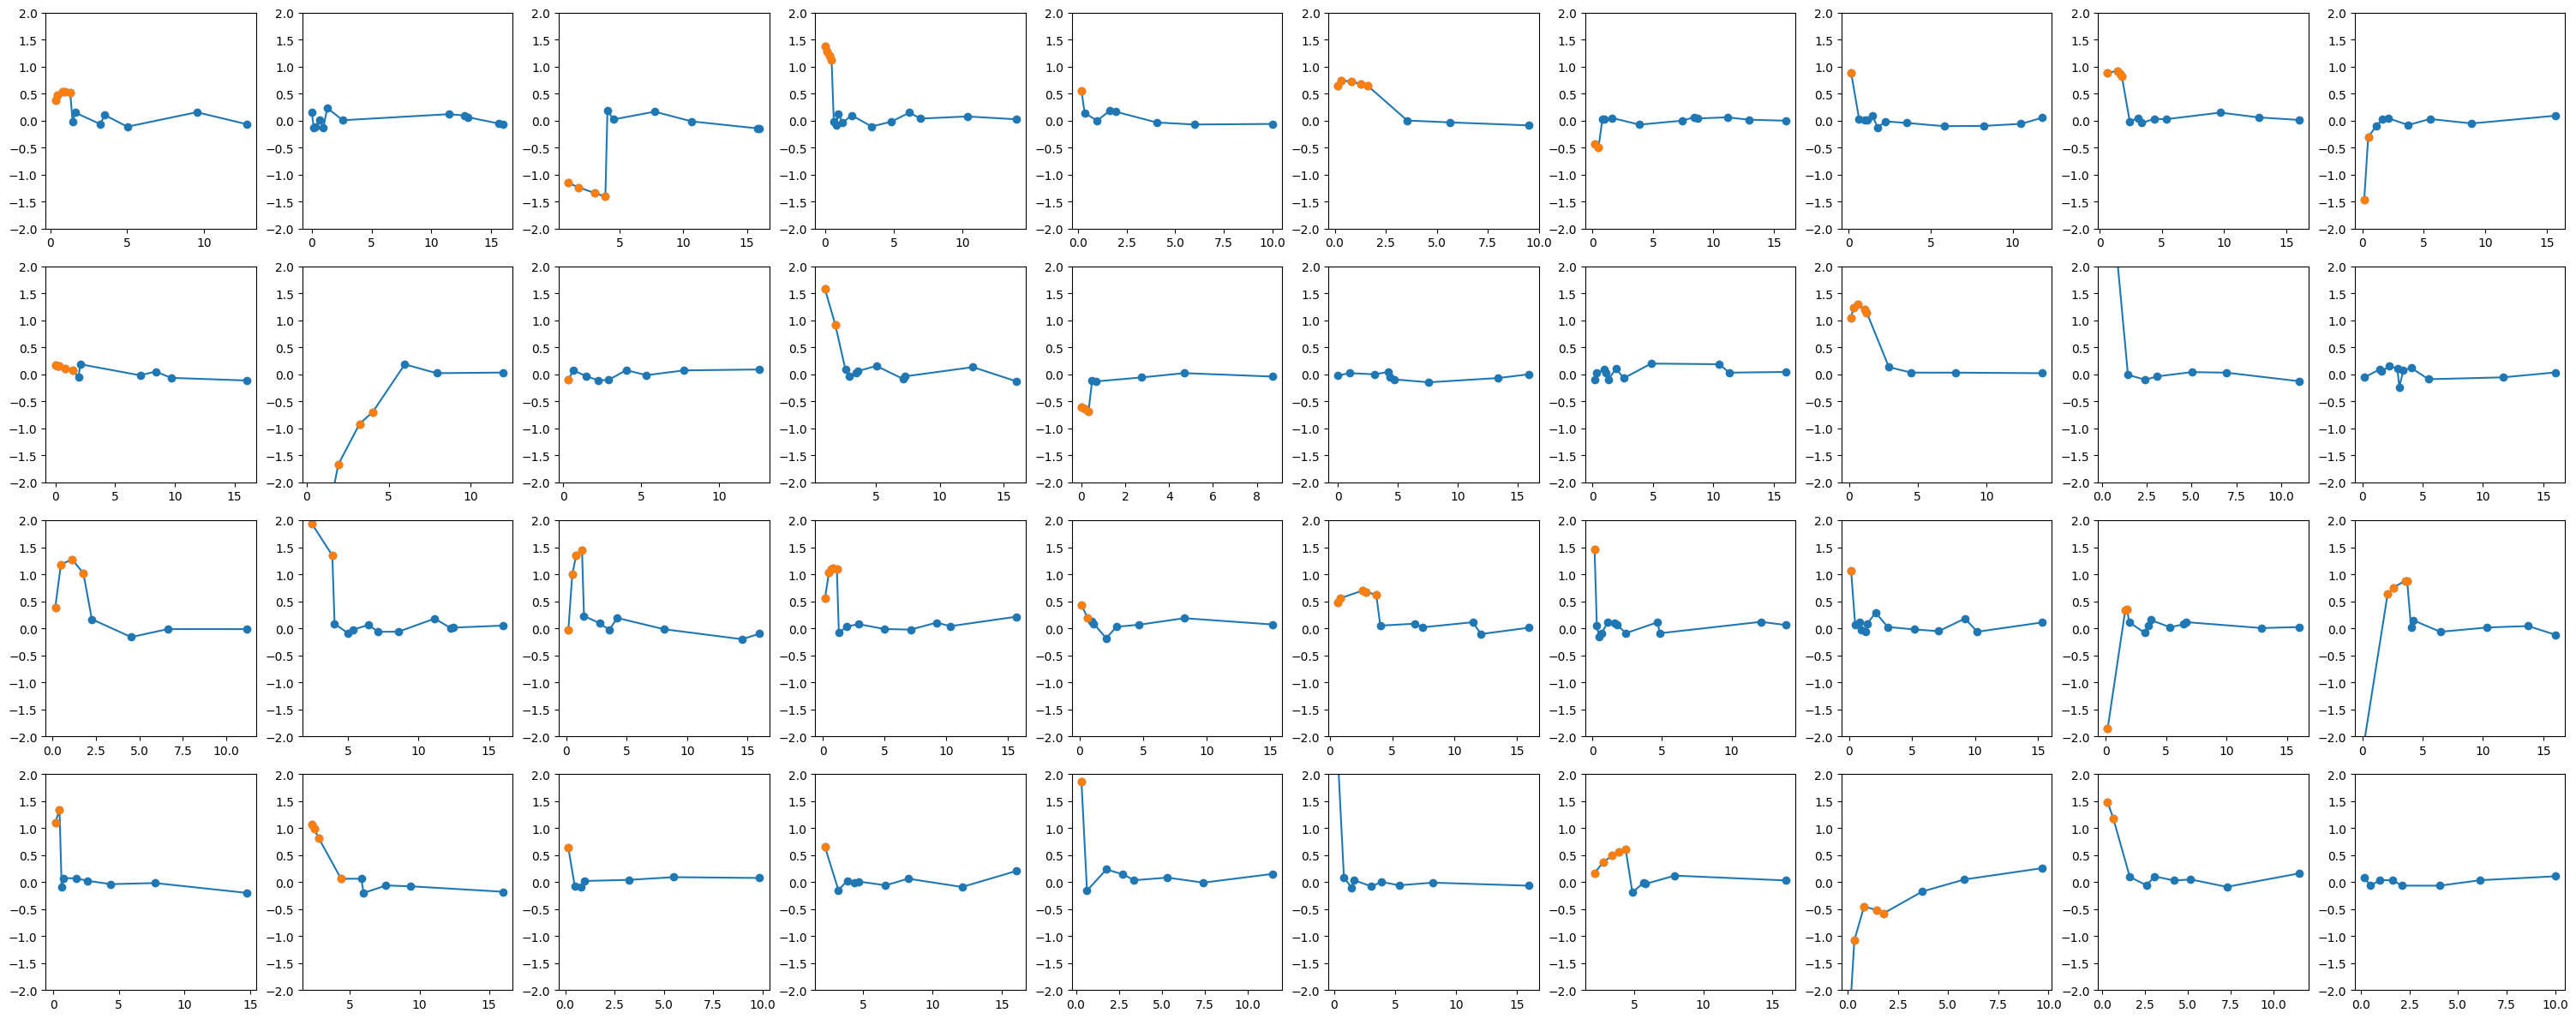

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

n = 40
use_log = False
fig, ax = plt.subplots(4, 10, figsize=(30, 12))

for n in range(0,10):
    T_pred = T[n].reshape(20).detach().cpu()
    X_pred = X[n].reshape(20).detach().cpu()
    M_pred = M[n].reshape(20).detach().cpu()
    t = t_past[n].reshape(5).detach().cpu()
    x = x_past[n].reshape(5).detach().cpu()
    m = batch.target_obs_mask[n].reshape(5).detach().cpu()

    ax[0,n].plot(T_pred[M_pred], X_pred[M_pred], label="GP Sample", marker="o",)
    ax[0,n].plot(t[m], x[m], label="Observations", marker="o", linestyle="None")
    if use_log:
        ax[0,n].set_ylim(1e-3, 1e1)
        ax[0,n].set_yscale('log')
    else:
        ax[0,n].set_ylim(-2, 2)

for i,n in enumerate(range(10,20)):
    T_pred = T[n].reshape(20).detach().cpu()
    X_pred = X[n].reshape(20).detach().cpu()
    M_pred = M[n].reshape(20).detach().cpu()
    t = t_past[n].reshape(5).detach().cpu()
    x = x_past[n].reshape(5).detach().cpu()
    m = batch.target_obs_mask[n].reshape(5).detach().cpu()

    ax[1,i].plot(T_pred[M_pred], X_pred[M_pred], label="GP Sample", marker="o",)
    ax[1,i].plot(t[m], x[m], label="Observations", marker="o", linestyle="None")
    if use_log:
        ax[1,i].set_ylim(1e-3, 1e1)
        ax[1,i].set_yscale('log')
    else:
        ax[1,i].set_ylim(-2, 2)

for i,n in enumerate(range(20,30)):
    T_pred = T[n].reshape(20).detach().cpu()
    X_pred = X[n].reshape(20).detach().cpu()
    M_pred = M[n].reshape(20).detach().cpu()
    t = t_past[n].reshape(5).detach().cpu()
    x = x_past[n].reshape(5).detach().cpu()
    m = batch.target_obs_mask[n].reshape(5).detach().cpu()

    ax[2,i].plot(T_pred[M_pred], X_pred[M_pred], label="GP Sample", marker="o",)
    ax[2,i].plot(t[m], x[m], label="Observations", marker="o", linestyle="None")
    if use_log:
        ax[2,i].set_ylim(1e-10, 1e1)
        ax[2,i].set_yscale('log')
    else:
        ax[2,i].set_ylim(-2, 2)

for i,n in enumerate(range(30, 40)):
    T_pred = T[n].reshape(20).detach().cpu()
    X_pred = X[n].reshape(20).detach().cpu()
    M_pred = M[n].reshape(20).detach().cpu()
    t = t_past[n].reshape(5).detach().cpu()
    x = x_past[n].reshape(5).detach().cpu()
    m = batch.target_obs_mask[n].reshape(5).detach().cpu()

    ax[3,i].plot(T_pred[M_pred], X_pred[M_pred], label="GP Sample", marker="o",)
    ax[3,i].plot(t[m], x[m], label="Observations", marker="o", linestyle="None")
    if use_log:
        ax[3,i].set_ylim(1e-10, 1e1)
        ax[3,i].set_yscale('log')
    else:
        ax[3,i].set_ylim(-2, 2)

plt.tight_layout()
plt.show()


In [15]:
GPR = GaussianProcessRegression(variance=0.1, length_scale=0.01, epsilon=0.0, transform='softplus')
X = GPR(
    t_query=T,  # (B, 1, N, 1)
    # t_cond=t_past,  # (B, 1, N, 1)
    # x_cond=x_past + 1e-8,    # (B, 1, M, 1)
    # mask_cond = batch.target_obs_mask,  # (B, 1, M)  — optional
    mask_query = M,  # (B, 1, N)  — optional
) 

# T, X, M, is_future = concat_past_and_future(t_past, x_past+ 1e-8, batch.target_obs_mask, t_future, x_future, batch.target_rem_sim_mask)


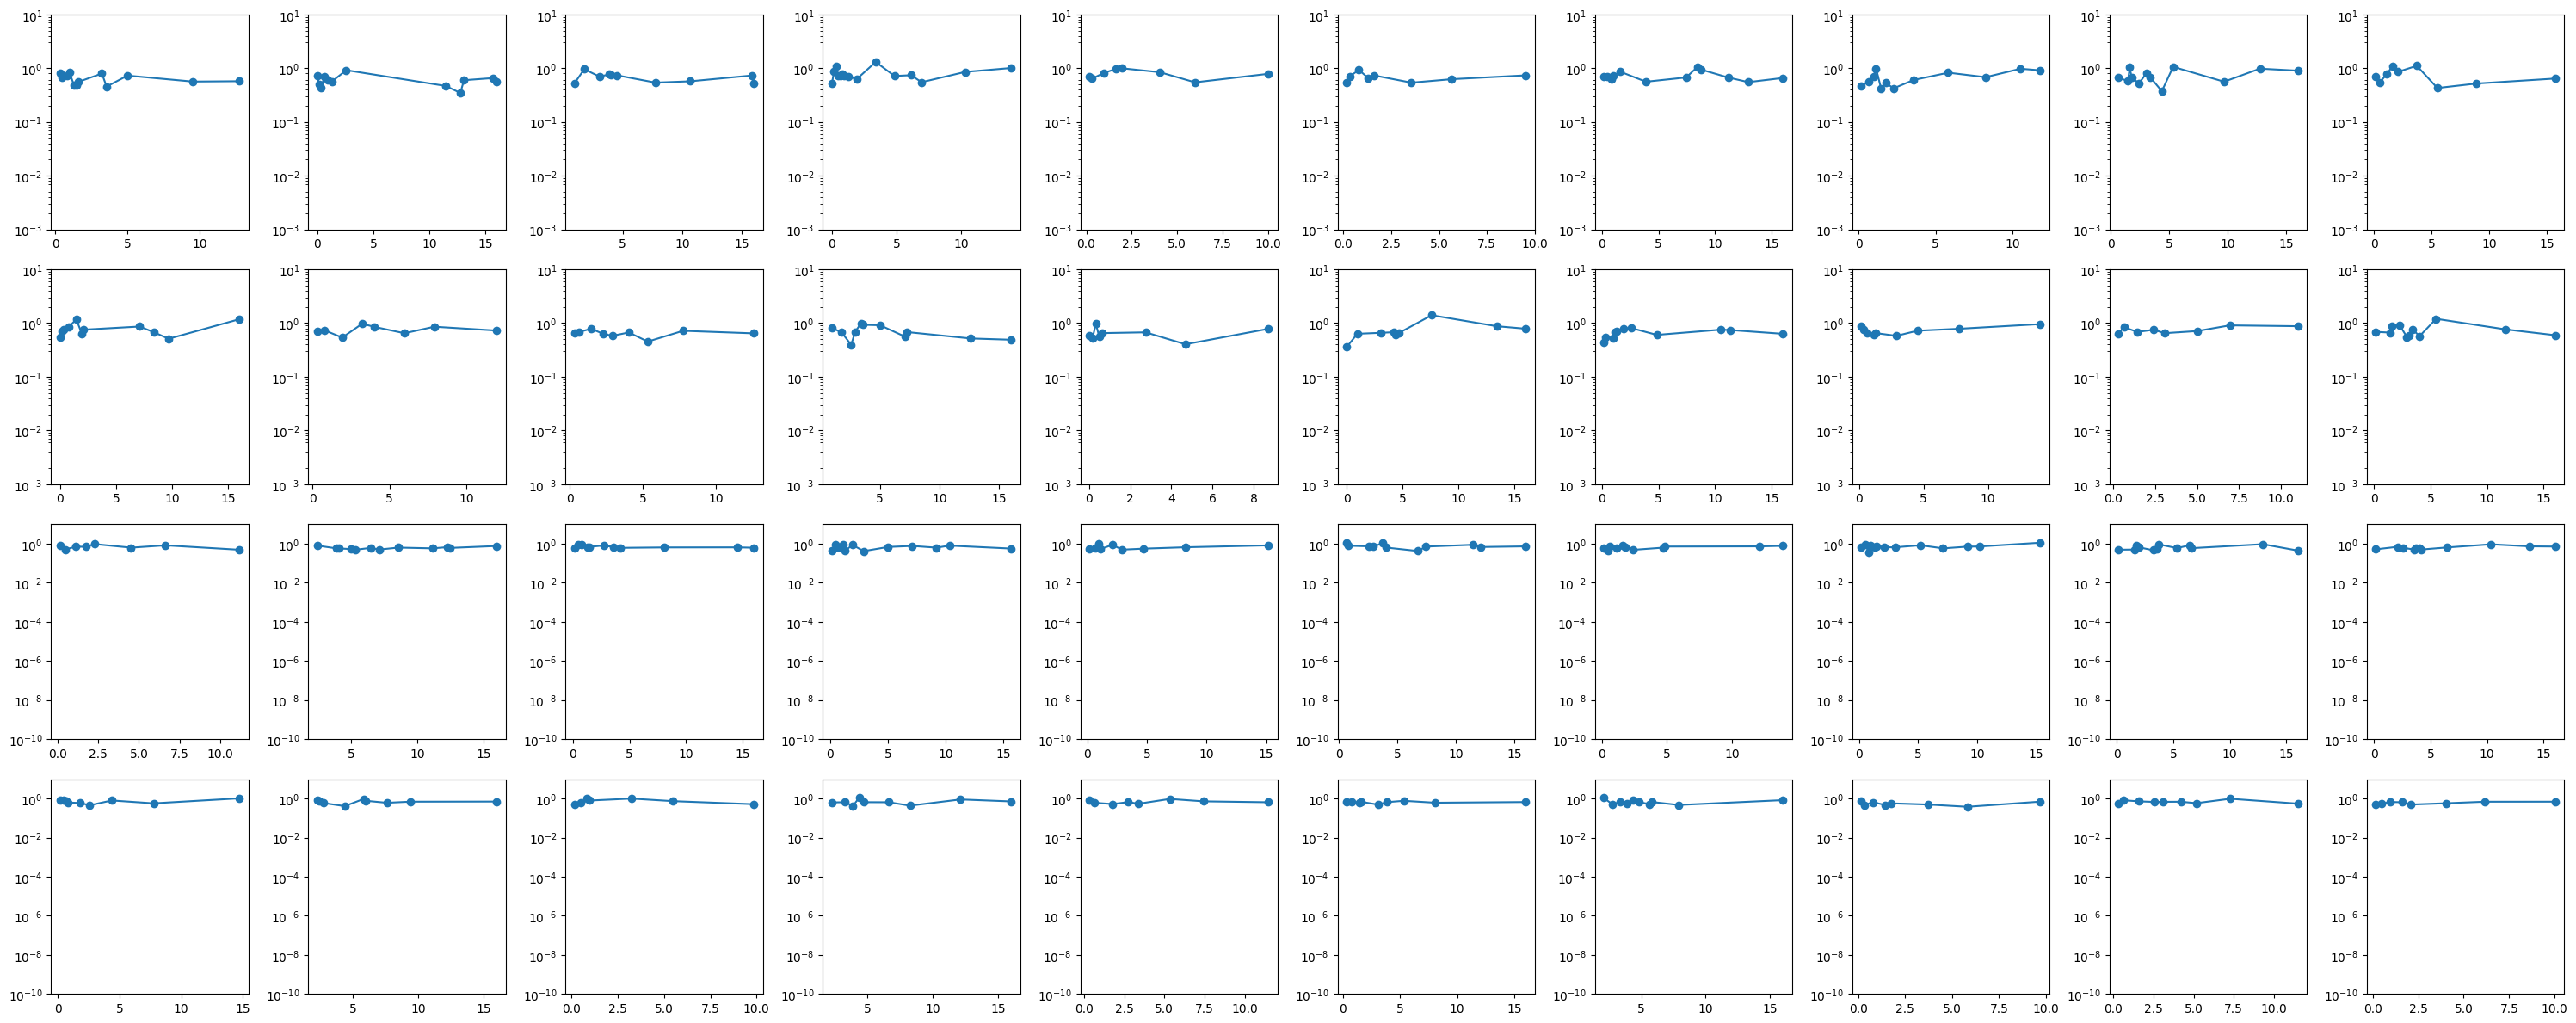

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt

n = 40
use_log = True
fig, ax = plt.subplots(4, 10, figsize=(30, 12))

for n in range(0,10):
    T_pred = T[n].reshape(20).detach().cpu()
    X_pred = X[n].reshape(20).detach().cpu()
    M_pred = M[n].reshape(20).detach().cpu()
    ax[0,n].plot(T_pred[M_pred], X_pred[M_pred], label="GP Sample", marker="o",)
    if use_log:
        ax[0,n].set_ylim(1e-3, 1e1)
        ax[0,n].set_yscale('log')
    else:
        ax[0,n].set_ylim(-2, 2)

for i,n in enumerate(range(10,20)):
    T_pred = T[n].reshape(20).detach().cpu()
    X_pred = X[n].reshape(20).detach().cpu()
    M_pred = M[n].reshape(20).detach().cpu()
    ax[1,i].plot(T_pred[M_pred], X_pred[M_pred], label="GP Sample", marker="o",)
    if use_log:
        ax[1,i].set_ylim(1e-3, 1e1)
        ax[1,i].set_yscale('log')
    else:
        ax[1,i].set_ylim(-2, 2)

for i,n in enumerate(range(20,30)):
    T_pred = T[n].reshape(20).detach().cpu()
    X_pred = X[n].reshape(20).detach().cpu()
    M_pred = M[n].reshape(20).detach().cpu()
    ax[2,i].plot(T_pred[M_pred], X_pred[M_pred], label="GP Sample", marker="o",)
    if use_log:
        ax[2,i].set_ylim(1e-10, 1e1)
        ax[2,i].set_yscale('log')
    else:
        ax[2,i].set_ylim(-2, 2)

for i,n in enumerate(range(30, 40)):
    T_pred = T[n].reshape(20).detach().cpu()
    X_pred = X[n].reshape(20).detach().cpu()
    M_pred = M[n].reshape(20).detach().cpu()
    ax[3,i].plot(T_pred[M_pred], X_pred[M_pred], label="GP Sample", marker="o",)
    if use_log:
        ax[3,i].set_ylim(1e-10, 1e1)
        ax[3,i].set_yscale('log')
    else:
        ax[3,i].set_ylim(-2, 2)

plt.tight_layout()
plt.show()


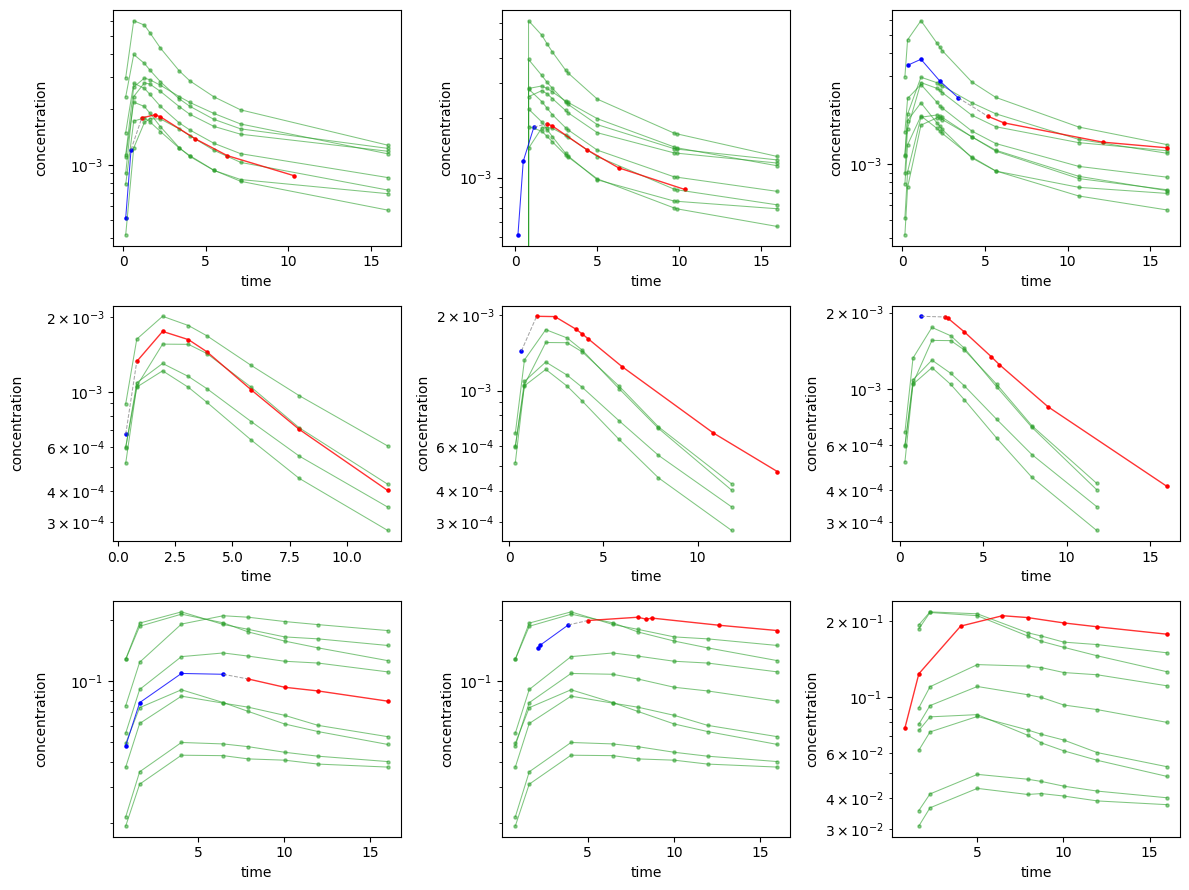

In [6]:
from pff.utils.plots.databatch_plot import plot_list_aicme_databatch, plot_aicme_databatch
plot_list_aicme_databatch(batches)

In [17]:
from typing import Union

import torch
import torch.nn as nn
from torchtyping import TensorType


class WhiteNoiseProcess(nn.Module):
    """
    White-noise process that mirrors the GaussianProcessRegression interface.
    The white-noise kernel is K(t, t') = σ² δ(t == t'),

    Parameters
    ----------
    variance  : output variance σ²
    epsilon    : small diagonal added to ensure positivity of padded-slot
                masking (matches GaussianProcessRegression convention)
    transform : "none" | "exp" | "softplus" — maps unconstrained samples
                to positive space (use "none" for unrestricted outputs)
    """

    def __init__(
        self,
        epsilon:    float = 1e-7,
        transform: str   = "softplus",
    ):
        super().__init__()
        self.epsilon    = epsilon
        self.transform = transform

    # ------------------------------------------------------------------

    def _forward_transform(self, x: torch.Tensor) -> torch.Tensor:
        if self.transform == "exp":
            return torch.exp(x)
        if self.transform == "softplus":
            return torch.nn.functional.softplus(x)
        return x

    def _masked_mean_std(self, x: torch.Tensor, m: torch.Tensor, eps: float):
        valid = m.bool()
        count = valid.sum(dim=-1, keepdim=True).clamp_min(1)
        mean = x.masked_fill(~valid, 0).sum(dim=-1, keepdim=True) / count
        var = ((x - mean).pow(2)).masked_fill(~valid, 0).sum(dim=-1, keepdim=True) / count
        return mean, var.clamp_min(eps**2).sqrt()

    def sample_prior(
        self,
        t_query:    TensorType["B", 1, "N", 1],
        mask_query: Union[TensorType["B", 1, "N"], None] = None,
    ) -> TensorType["B", 1, "N", 1]:
        """
        Sample independently from N(0, σ²) at each query time point.

        Parameters
        ----------
        t_query    : (B, 1, N, 1)  query time points, zero-padded.
        mask_query : (B, *, N) bool, optional — True = real time point.
                     Inferred from t_query > 0 when not supplied.

        Returns
        -------
        x_query : (B, 1, N, 1)
            White-noise sample; padded slots are zeroed out.
        """
        B, _, N, _ = t_query.shape
        device, dtype = t_query.device, t_query.dtype
        tq = t_query.reshape(B, N)                              # (B, N)
        mask_query = mask_query.reshape(B, N) if  mask_query is not None else torch.ones_like(tq)     # (B, N)
        x_query = torch.randn(B, N, device=device, dtype=dtype) 
        x_query = self._forward_transform(x_query) * mask_query   
        return x_query.reshape(B, 1, N, 1)

    # ------------------------------------------------------------------
    def forward(
        self,
        t_query:    TensorType["B", 1, "N", 1],
        t_cond:     Union[TensorType["B", 1, "M", 1], None] = None,
        x_cond:     Union[TensorType["B", 1, "M", 1], None] = None,
        mask_query: Union[TensorType["B", 1, "N"], None] = None,
        mask_cond:  Union[TensorType["B", 1, "M"], None] = None,
    ) -> TensorType["B", 1, "N", 1]:
        """
        Sample white noise centred on the empirical mean of the conditioning

        Parameters
        ----------
        t_query    : (B, 1, N, 1)  query time points.
        t_cond     : (B, 1, M, 1)  conditioning time points (only used to
                     infer mask when mask_cond is None).
        x_cond     : (B, 1, M, 1)  conditioning observations in data space.
        mask_query : (B, *, N) bool, optional.
        mask_cond  : (B, *, M) bool, optional — True = real conditioning point.
                     Inferred from t_cond > 0 when not supplied.
        Returns
        -------
        x_query : (B, 1, N, 1)
        """
        B, _, N, _ = t_query.shape
        device, dtype = t_query.device, t_query.dtype
        if t_cond is None or x_cond is None:
            return self.sample_prior(t_query, mask_query=mask_query)

        M = t_cond.shape[2]
        tq = t_query.reshape(B, N)
        tc = t_cond.reshape(B, M)
        xc = x_cond.reshape(B, M)
        mask_cond = mask_cond.reshape(B, M) if mask_cond is not None else torch.ones_like(tc)
        mask_query = mask_query.reshape(B, N) if mask_query is not None else torch.ones_like(tq)

        mu_cond, std_cond = self._masked_mean_std(xc, mask_cond, 1e-7)  # (B, 1), (B, 1)         
        z = torch.randn(B, N, device=device, dtype=dtype)
        x_query  = mu_cond + z * std_cond # (B, N)

        # No observations 
        has_cond_data = mask_cond.any(dim=-1)                   
        if not has_cond_data.all():
            x_query[~has_cond_data] = z[~has_cond_data]

        # Exactly 1 observation: unit std 
        has_1_obs   = (mask_cond.sum(dim=-1) == 1)                  
        single_val  = (xc * mask_cond.float()).sum(dim=-1, keepdim=True) 
        if has_1_obs.any():
            x_query[has_1_obs] = single_val[has_1_obs] + z[has_1_obs]

        x_query = self._forward_transform(x_query) * mask_query
        return x_query.reshape(B, 1, N, 1)

In [18]:

WN = WhiteNoiseProcess(epsilon=0.5, transform='softplus')
x_future = WN(
    t_query=t_future,  # (B, 1, N, 1)
    t_cond=t_past,  # (B, 1, N, 1)
    x_cond=x_past + 1e-8,    # (B, 1, M, 1)
    mask_cond = batch.target_obs_mask,  # (B, 1, M)  — optional
    mask_query = batch.target_rem_sim_mask,  # (B, 1, N)  — optional
) 

T, X, M, is_future = concat_past_and_future(t_past, x_past+ 1e-8, batch.target_obs_mask, t_future, x_future, batch.target_rem_sim_mask)


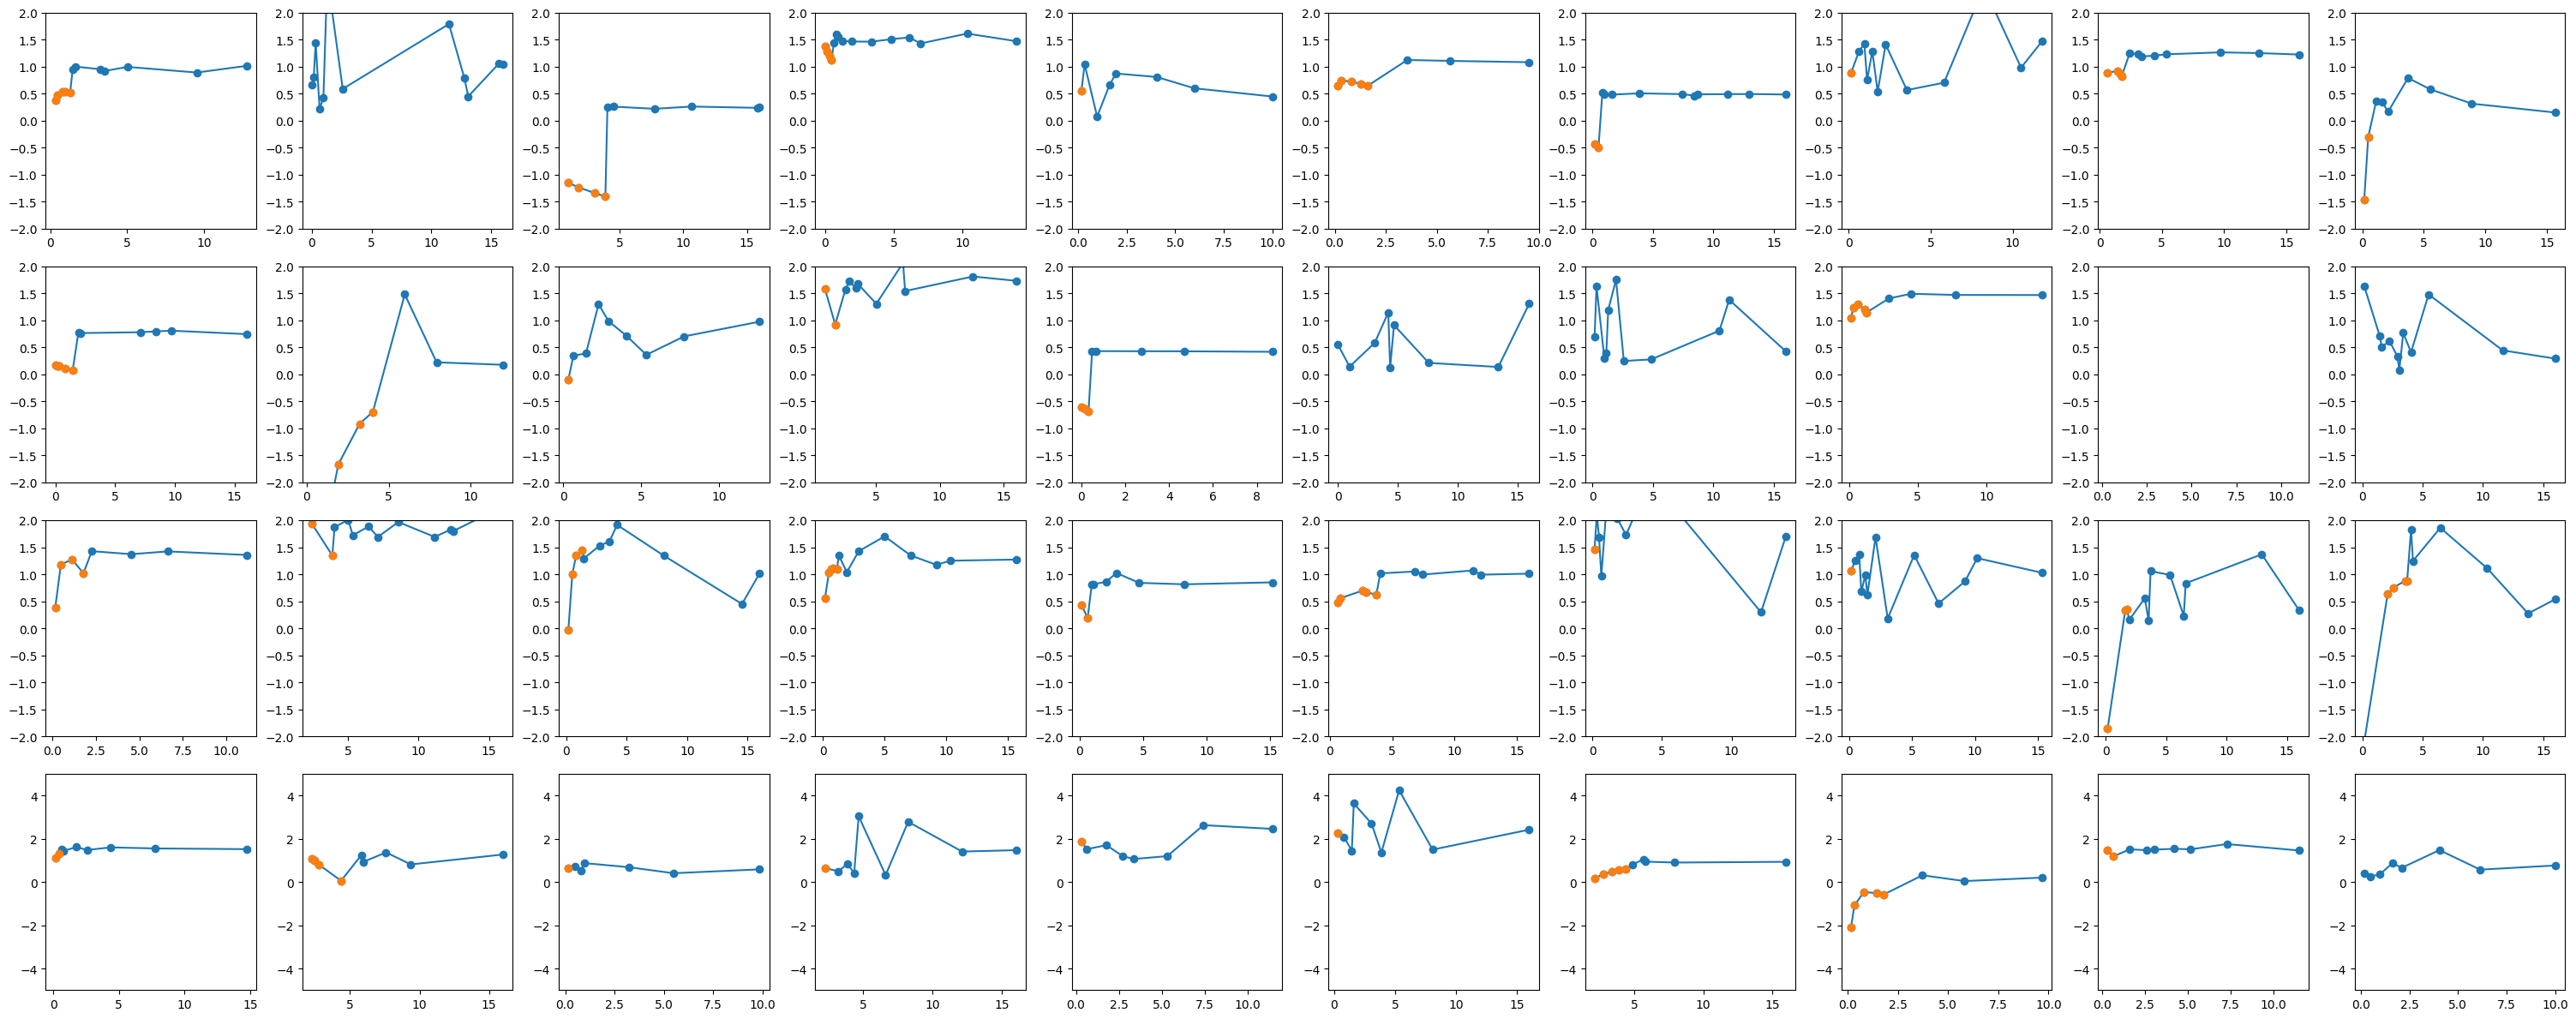

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt

n = 40
use_log = False
fig, ax = plt.subplots(4, 10, figsize=(30, 12))

for n in range(0,10):
    T_pred = T[n].reshape(20).detach().cpu()
    X_pred = X[n].reshape(20).detach().cpu()
    M_pred = M[n].reshape(20).detach().cpu()
    t = t_past[n].reshape(5).detach().cpu()
    x = x_past[n].reshape(5).detach().cpu()
    m = batch.target_obs_mask[n].reshape(5).detach().cpu()

    ax[0,n].plot(T_pred[M_pred], X_pred[M_pred], label="GP Sample", marker="o",)
    ax[0,n].plot(t[m], x[m], label="Observations", marker="o", linestyle="None")
    if use_log:
        ax[0,n].set_ylim(1e-3, 1e1)
        ax[0,n].set_yscale('log')
    else:
        ax[0,n].set_ylim(-2, 2)

for i,n in enumerate(range(10,20)):
    T_pred = T[n].reshape(20).detach().cpu()
    X_pred = X[n].reshape(20).detach().cpu()
    M_pred = M[n].reshape(20).detach().cpu()
    t = t_past[n].reshape(5).detach().cpu()
    x = x_past[n].reshape(5).detach().cpu()
    m = batch.target_obs_mask[n].reshape(5).detach().cpu()

    ax[1,i].plot(T_pred[M_pred], X_pred[M_pred], label="GP Sample", marker="o",)
    ax[1,i].plot(t[m], x[m], label="Observations", marker="o", linestyle="None")
    if use_log:
        ax[1,i].set_ylim(1e-3, 1e1)
        ax[1,i].set_yscale('log')
    else:
        ax[1,i].set_ylim(-2, 2)

for i,n in enumerate(range(20,30)):
    T_pred = T[n].reshape(20).detach().cpu()
    X_pred = X[n].reshape(20).detach().cpu()
    M_pred = M[n].reshape(20).detach().cpu()
    t = t_past[n].reshape(5).detach().cpu()
    x = x_past[n].reshape(5).detach().cpu()
    m = batch.target_obs_mask[n].reshape(5).detach().cpu()

    ax[2,i].plot(T_pred[M_pred], X_pred[M_pred], label="GP Sample", marker="o",)
    ax[2,i].plot(t[m], x[m], label="Observations", marker="o", linestyle="None")
    if use_log:
        ax[2,i].set_ylim(1e-10, 1e1)
        ax[2,i].set_yscale('log')
    else:
        ax[2,i].set_ylim(-2, 2)

for i,n in enumerate(range(30, 40)):
    T_pred = T[n].reshape(20).detach().cpu()
    X_pred = X[n].reshape(20).detach().cpu()
    M_pred = M[n].reshape(20).detach().cpu()
    t = t_past[n].reshape(5).detach().cpu()
    x = x_past[n].reshape(5).detach().cpu()
    m = batch.target_obs_mask[n].reshape(5).detach().cpu()

    ax[3,i].plot(T_pred[M_pred], X_pred[M_pred], label="GP Sample", marker="o",)
    ax[3,i].plot(t[m], x[m], label="Observations", marker="o", linestyle="None")
    if use_log:
        ax[3,i].set_ylim(1e-10, 1e1)
        ax[3,i].set_yscale('log')
    else:
        ax[3,i].set_ylim(-5, 5)

plt.tight_layout()
plt.show()

